In [1]:
from modules.utils import merge_devtest_csvs
from modules.viz import ConfigLookup, metric_x_point
from pathlib import Path
import numpy as np
import pandas as pd

In [9]:
# compiling dfs
folder = Path('./output/reconstr_grid3')
# dev = pd.read_csv(folder/'dev.csv')
# test = pd.read_csv(folder/'test.csv')

subfolders = ['t1', 't2', 't3', 't4']
dev = merge_devtest_csvs(folder, subfolders, 'dev.csv', save=True)
test = merge_devtest_csvs(folder, subfolders, 'test.csv', save=True)

# get confs, update
confs = ConfigLookup(
    keys=['learnable','libnorm','znorm'],
    configs=dev['config'].unique().tolist(),
    path=folder,
    save=True,
).data

# merge with confs
dev = pd.merge(confs,dev,on='config')
test = pd.merge(confs,test,on='config')

In [10]:
test['norm_class'] = test["config"].str.extract(r"normclass(.*?)_normkwargs")
test

,learnable,libnorm,znorm,config,trial,metric,value,norm_class
0,False,False,False,normclassRawCounts_normkwargsLearnableFalselib...,0,loss,3.758737e+08,RawCounts
1,False,False,False,normclassRawCounts_normkwargsLearnableFalselib...,0,mse,1.866829e+01,RawCounts
2,False,False,False,normclassRawCounts_normkwargsLearnableFalselib...,0,rmse,4.320682e+00,RawCounts
3,False,False,False,normclassRawCounts_normkwargsLearnableFalselib...,0,mae,3.961372e+00,RawCounts
4,False,False,False,normclassRawCounts_normkwargsLearnableFalselib...,0,r2,-3.815272e+00,RawCounts
...,...,...,...,...,...,...,...,...
12955,True,True,True,normclassNBVST_normkwargsLearnableTruelibnormT...,119,mse,5.683213e-01,NBVST
12956,True,True,True,normclassNBVST_normkwargsLearnableTruelibnormT...,119,rmse,7.538708e-01,NBVST
12957,True,True,True,normclassNBVST_normkwargsLearnableTruelibnormT...,119,mae,5.046019e-01,NBVST
12958,True,True,True,normclassNBVST_normkwargsLearnableTruelibnormT...,119,r2,8.535616e-01,NBVST


In [11]:
test2 = test[test['norm_class']!='RawCounts']
test2

,learnable,libnorm,znorm,config,trial,metric,value,norm_class
1440,False,False,False,normclassLogCounts_normkwargsLearnableFalselib...,0,loss,0.773692,LogCounts
1441,False,False,False,normclassLogCounts_normkwargsLearnableFalselib...,0,mse,0.757993,LogCounts
1442,False,False,False,normclassLogCounts_normkwargsLearnableFalselib...,0,rmse,0.870628,LogCounts
1443,False,False,False,normclassLogCounts_normkwargsLearnableFalselib...,0,mae,0.612974,LogCounts
1444,False,False,False,normclassLogCounts_normkwargsLearnableFalselib...,0,r2,0.804484,LogCounts
...,...,...,...,...,...,...,...,...
12955,True,True,True,normclassNBVST_normkwargsLearnableTruelibnormT...,119,mse,0.568321,NBVST
12956,True,True,True,normclassNBVST_normkwargsLearnableTruelibnormT...,119,rmse,0.753871,NBVST
12957,True,True,True,normclassNBVST_normkwargsLearnableTruelibnormT...,119,mae,0.504602,NBVST
12958,True,True,True,normclassNBVST_normkwargsLearnableTruelibnormT...,119,r2,0.853562,NBVST


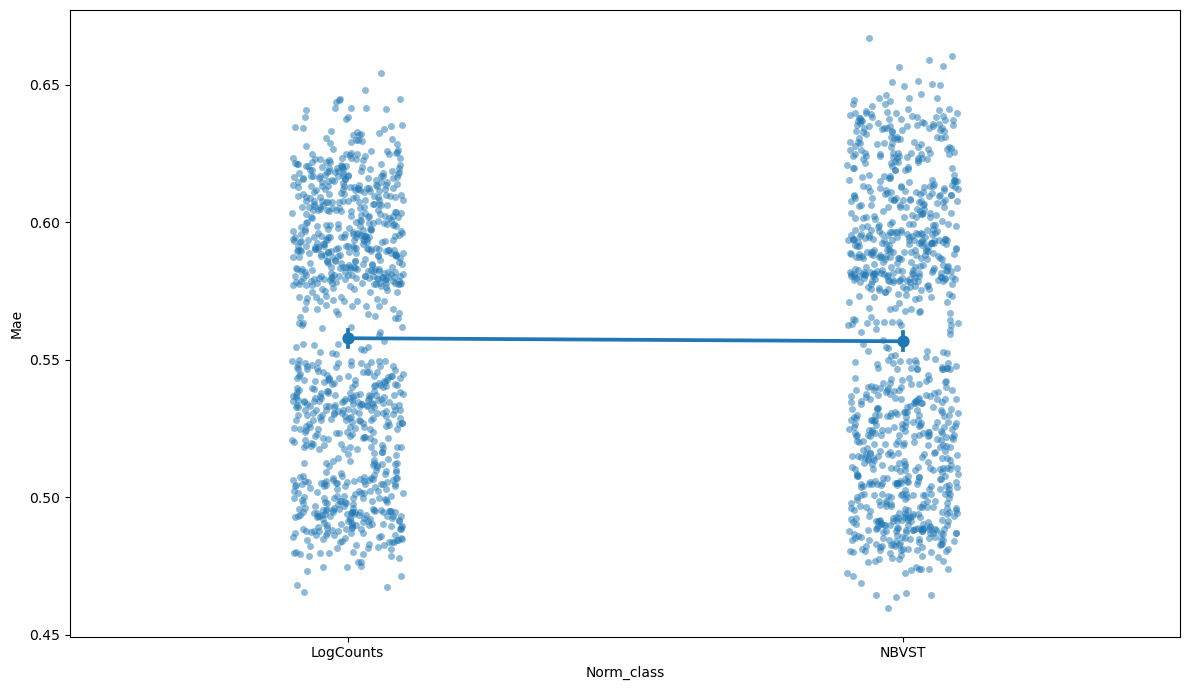

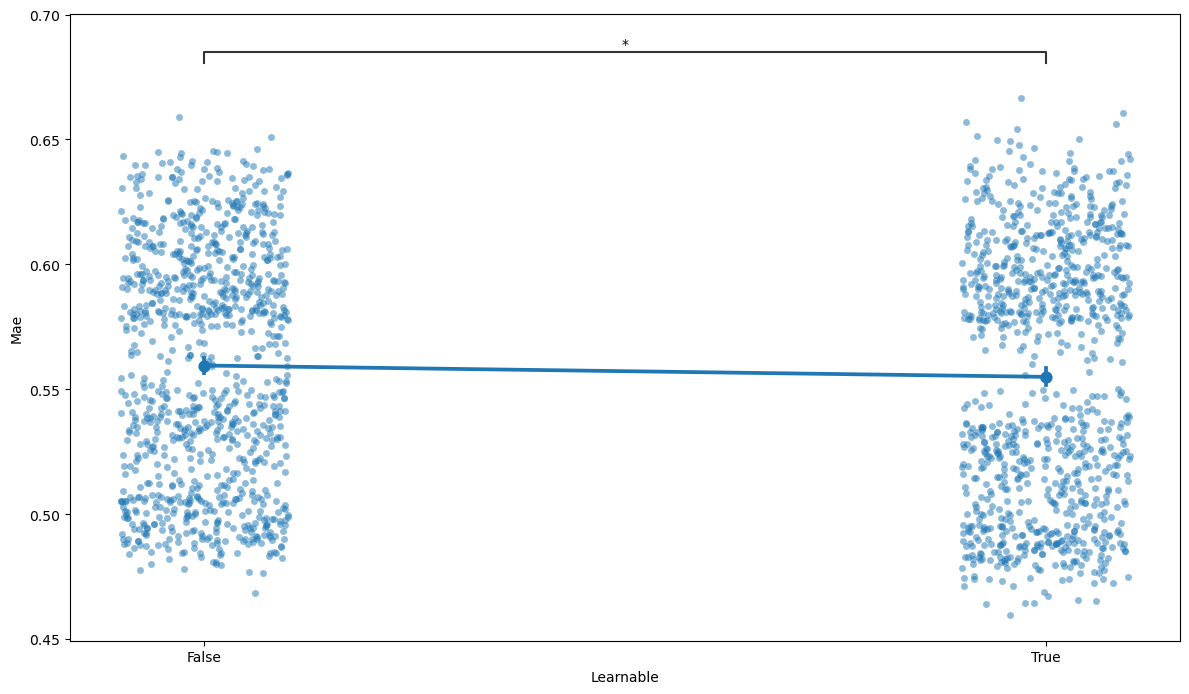

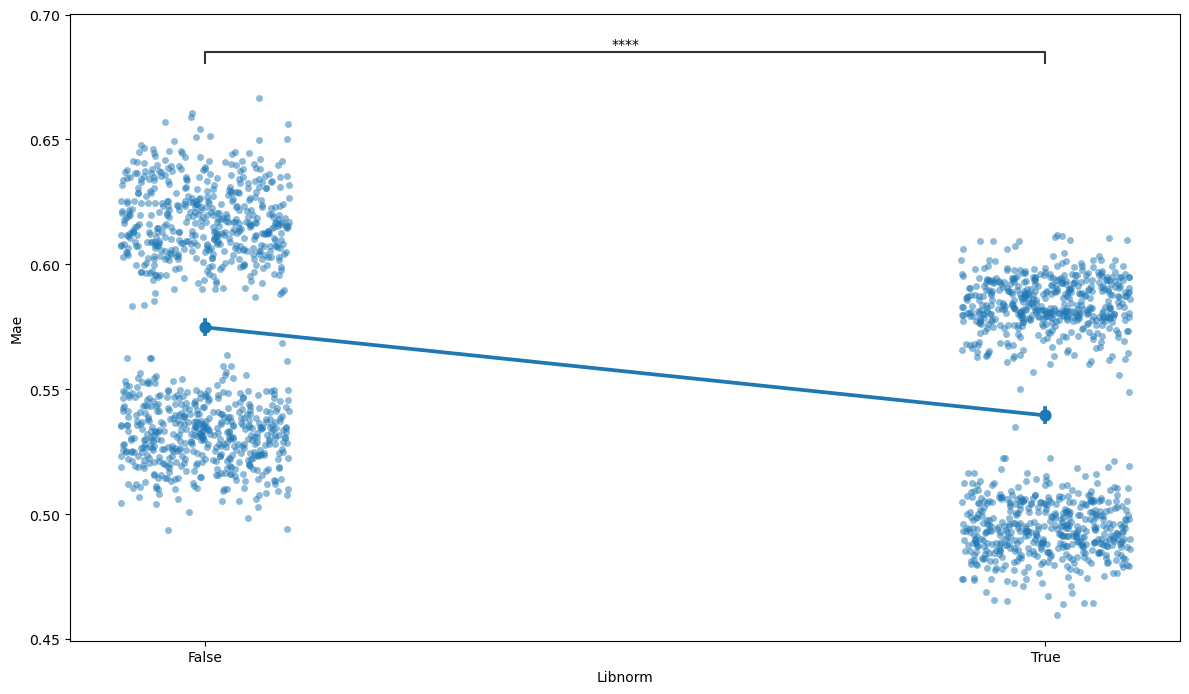

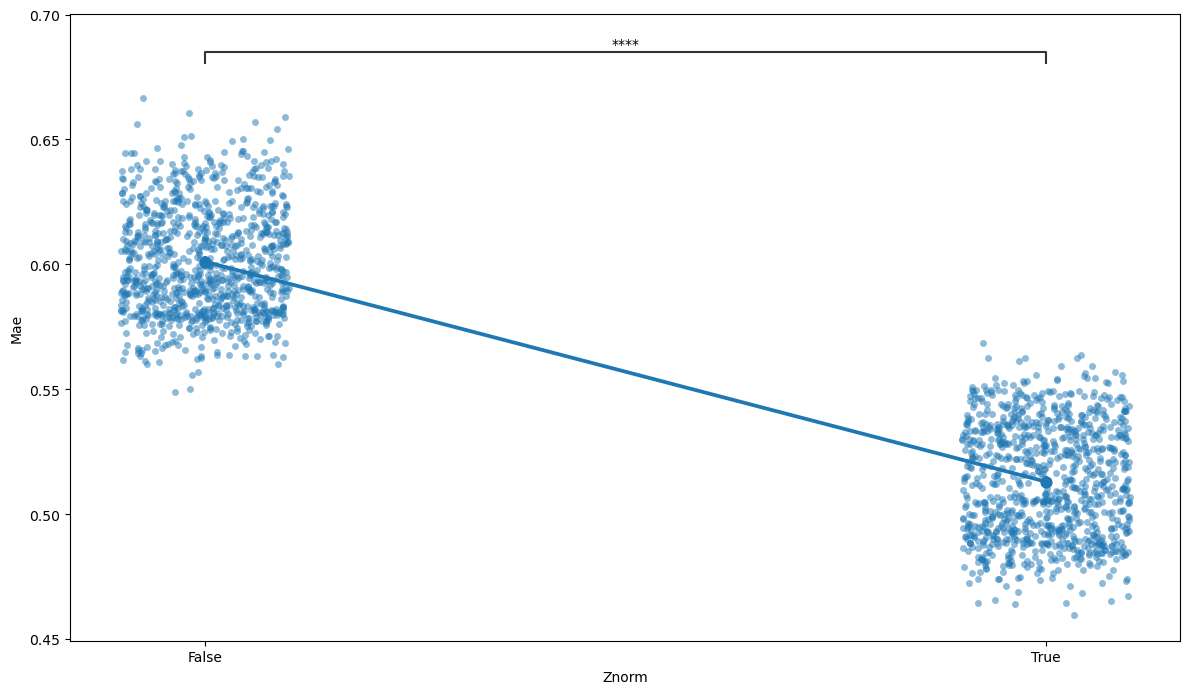

In [12]:
metric_x_point(
    df=test2, 
    cols=['norm_class', 'learnable','libnorm','znorm'],
    metrics=['mae'],
    figsize=(12,7),
    strip=True,
    sig=True
)

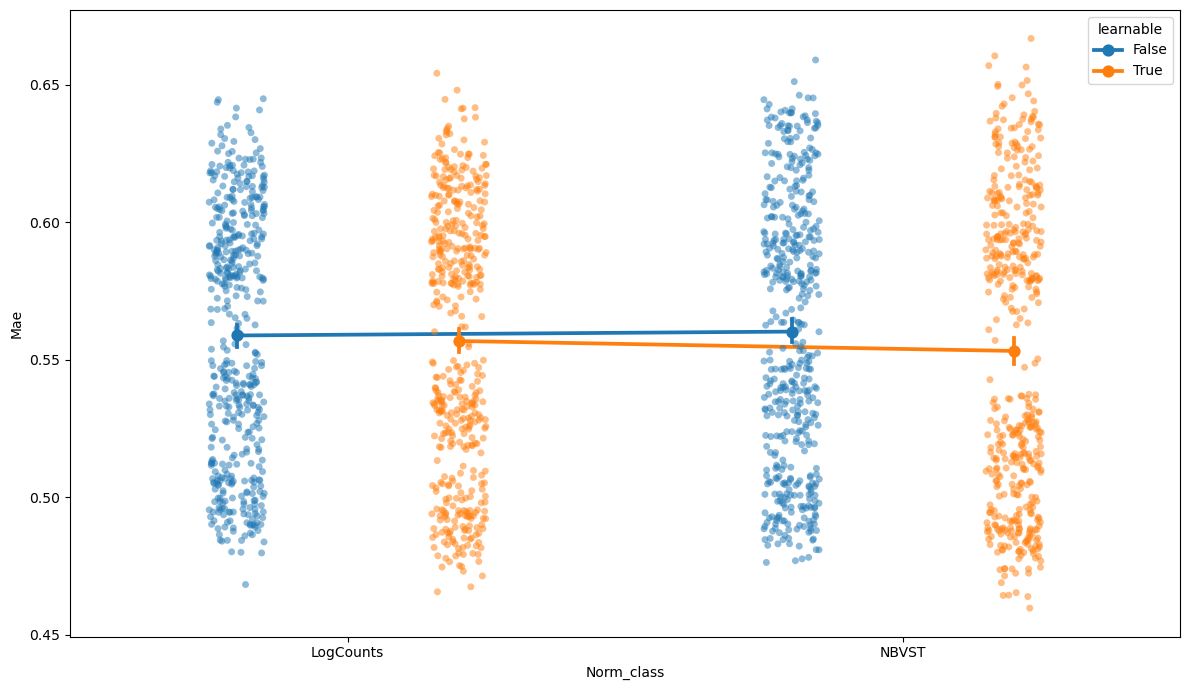

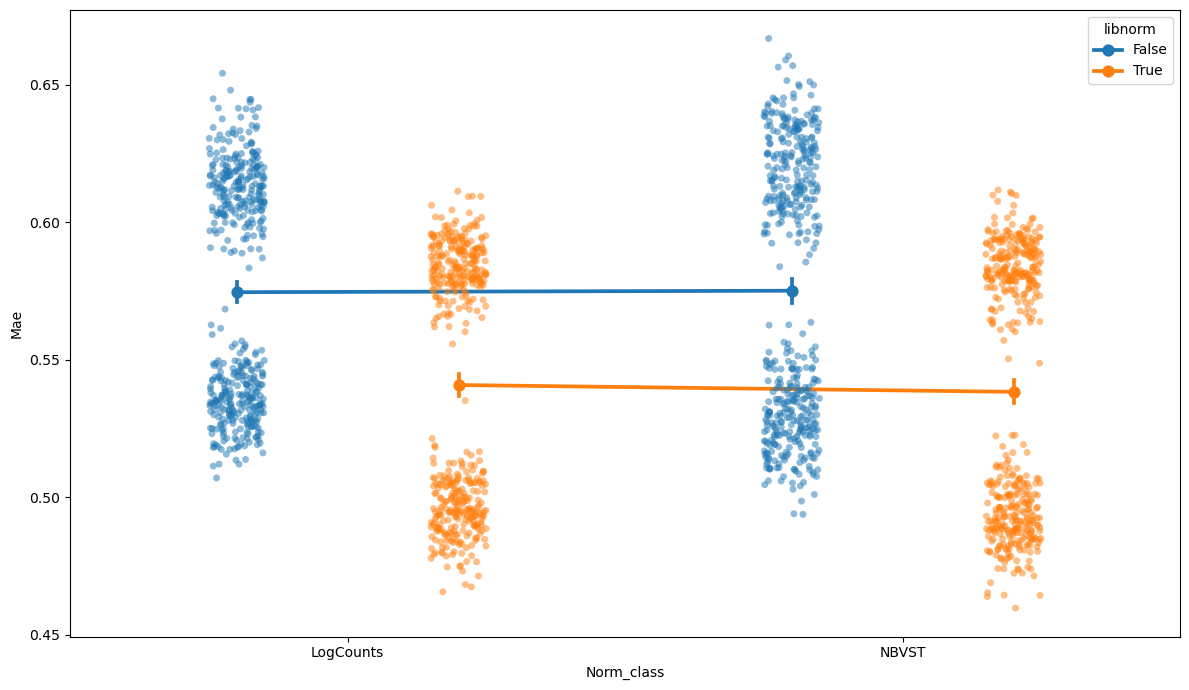

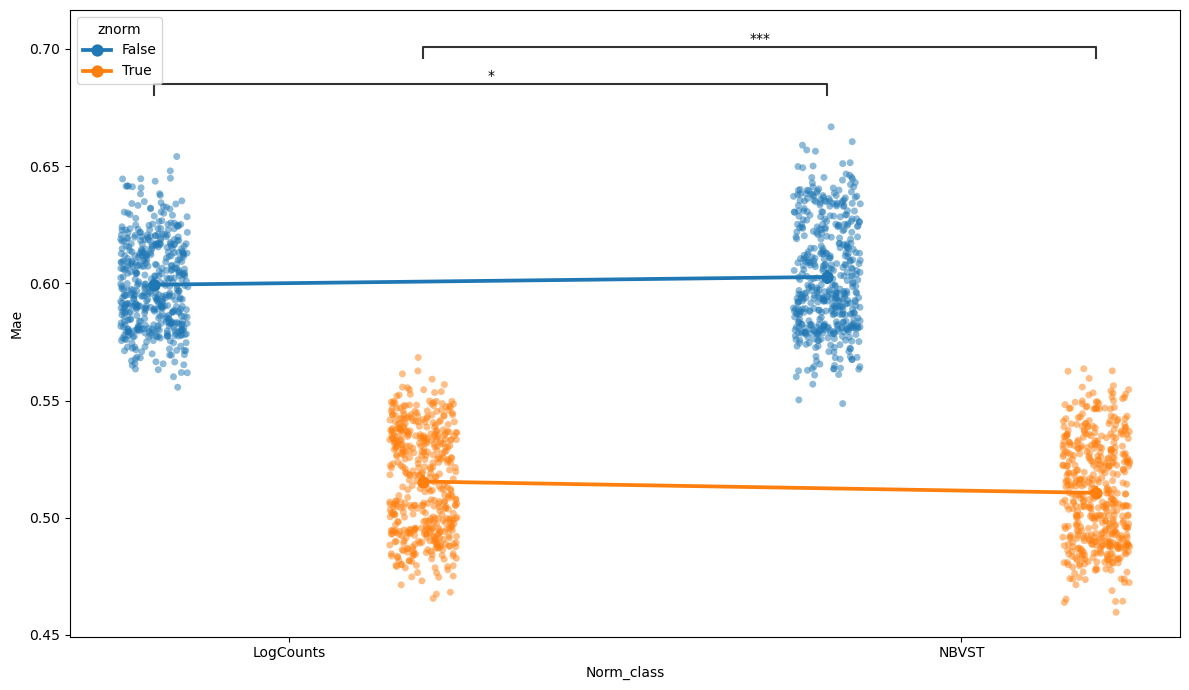

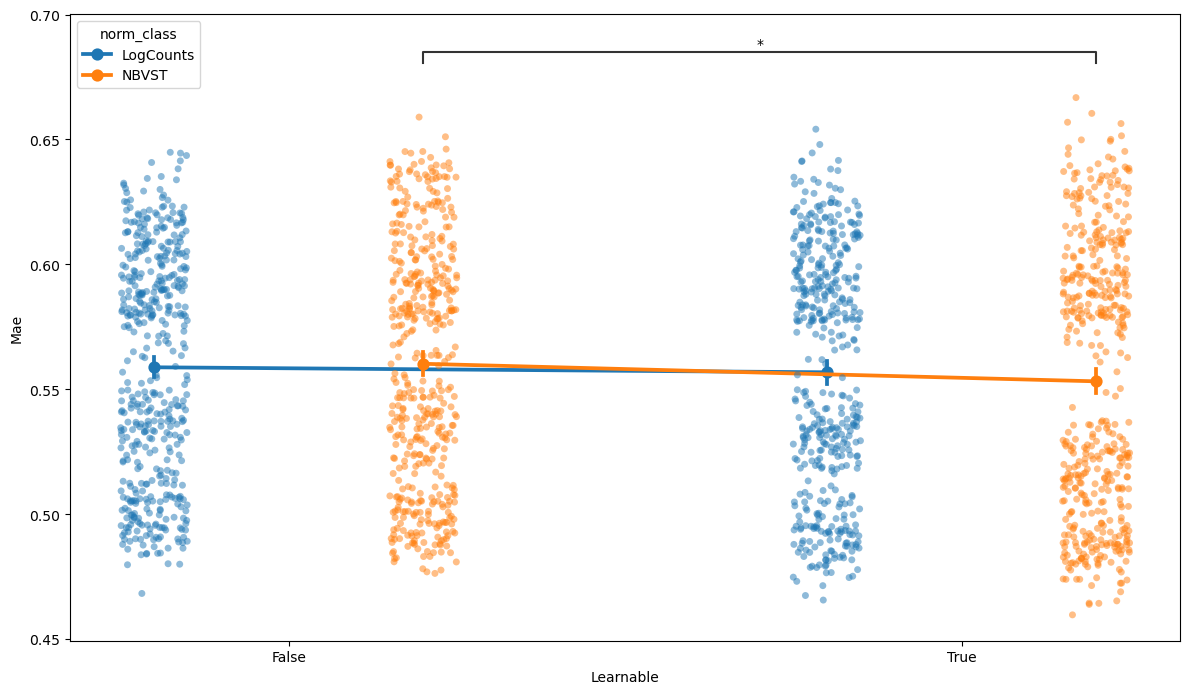

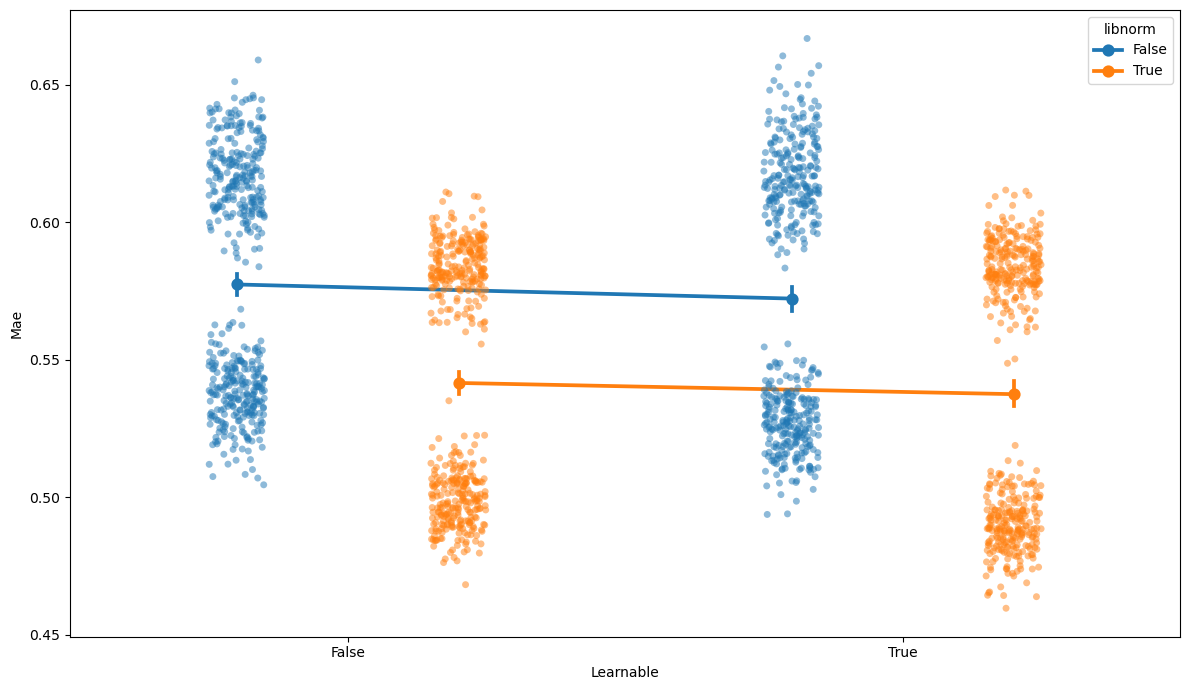

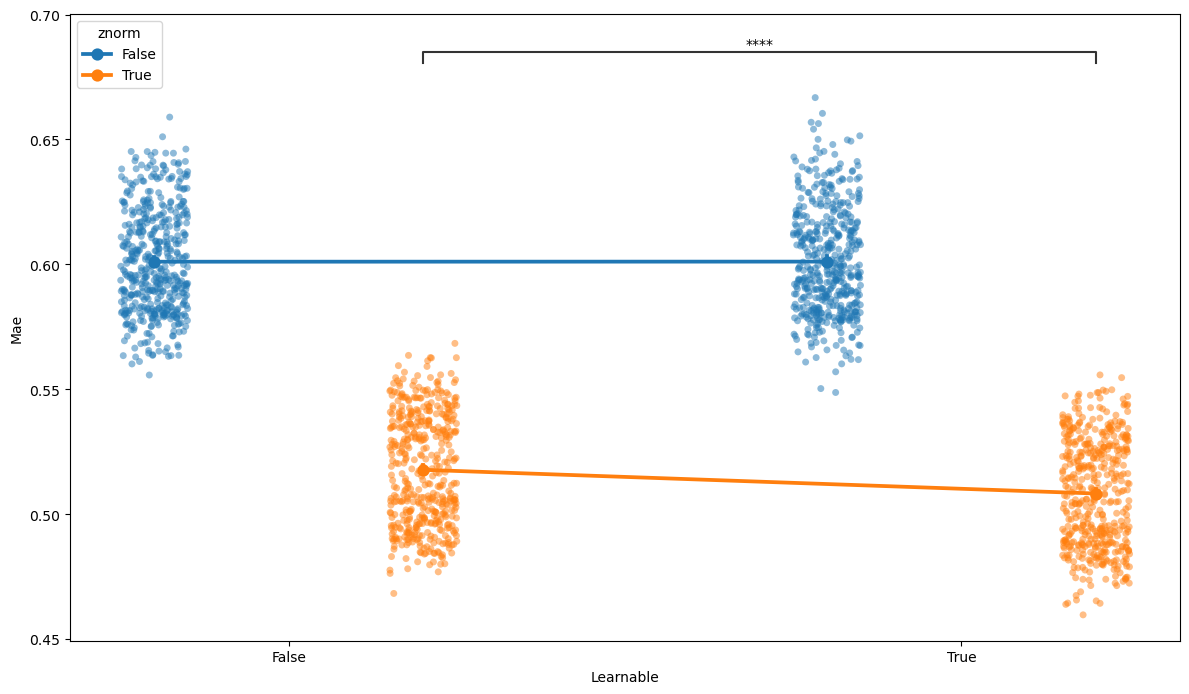

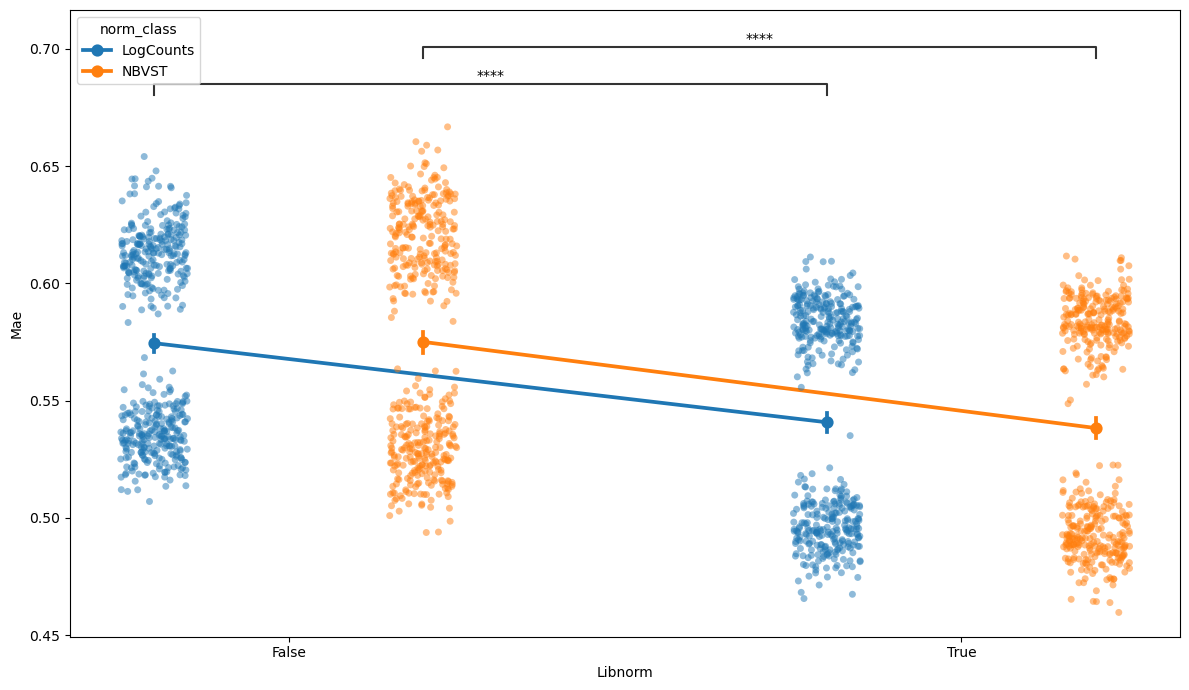

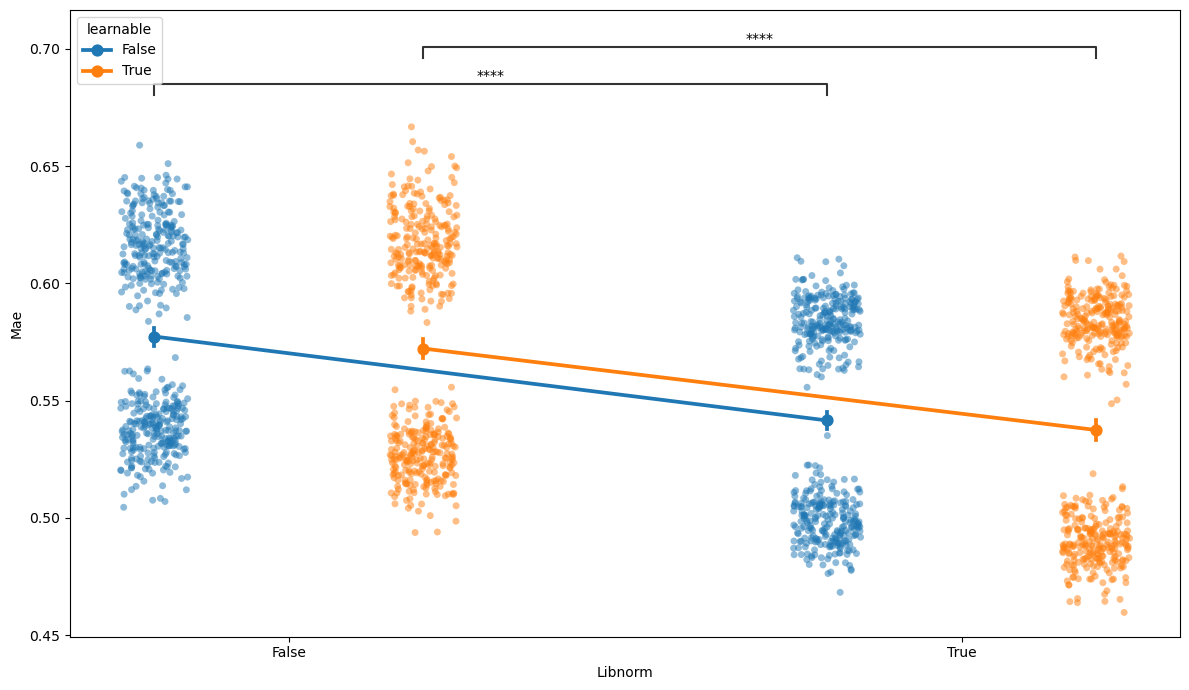

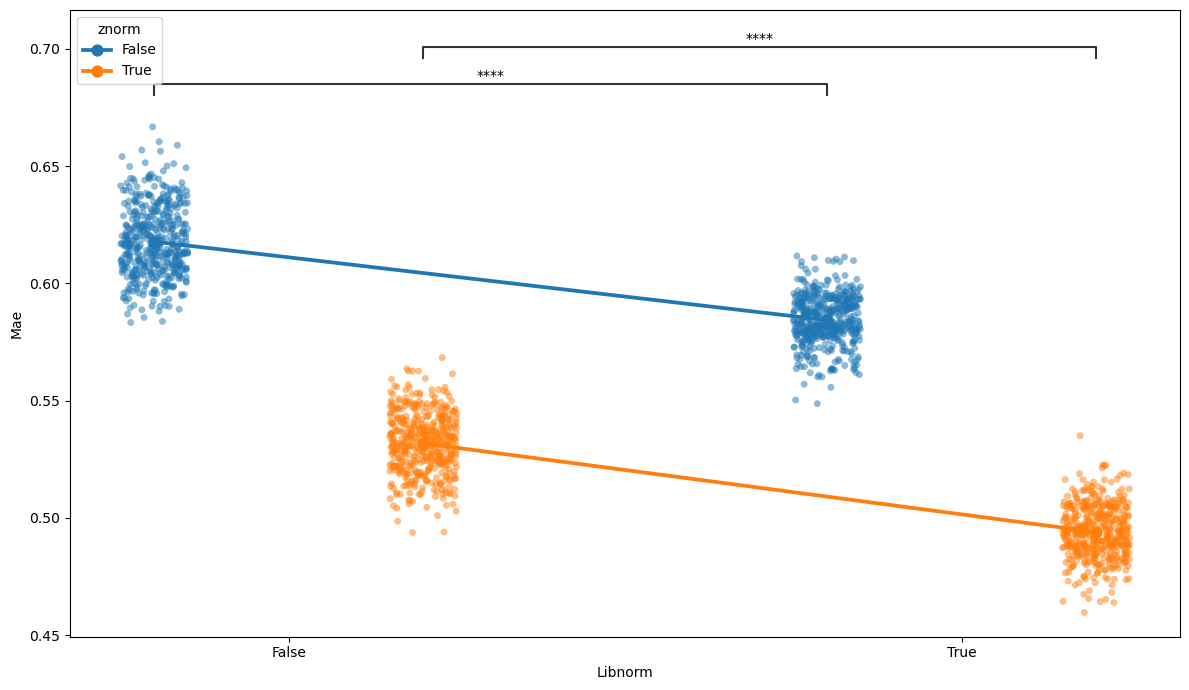

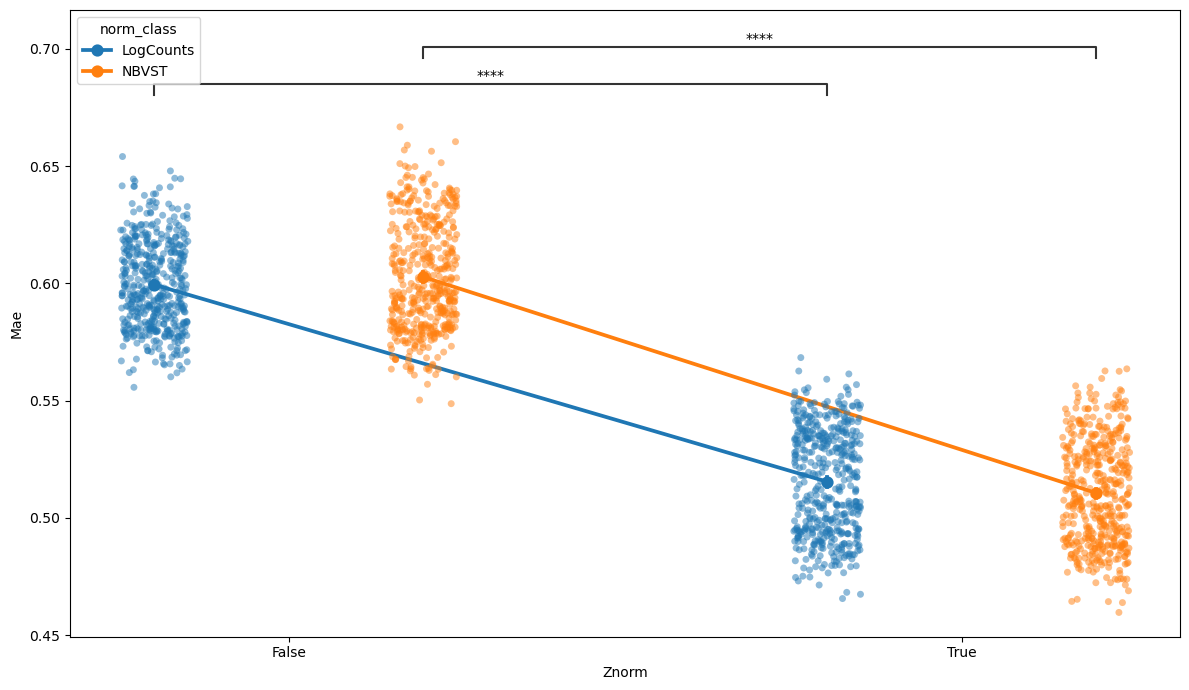

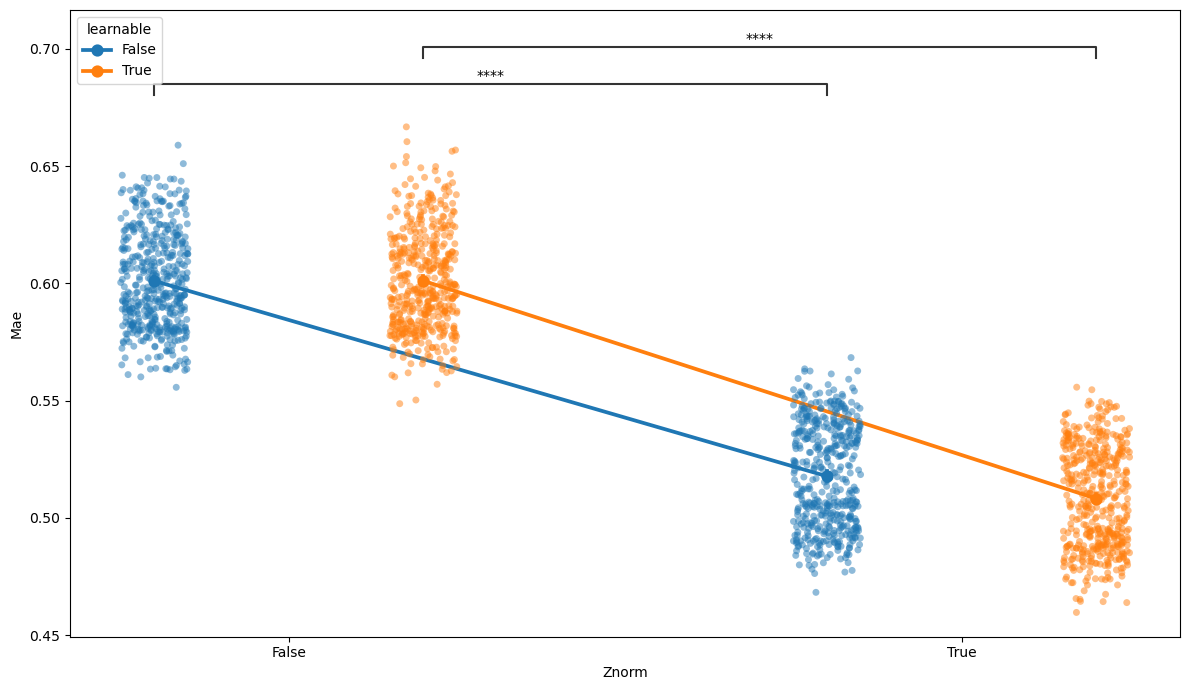

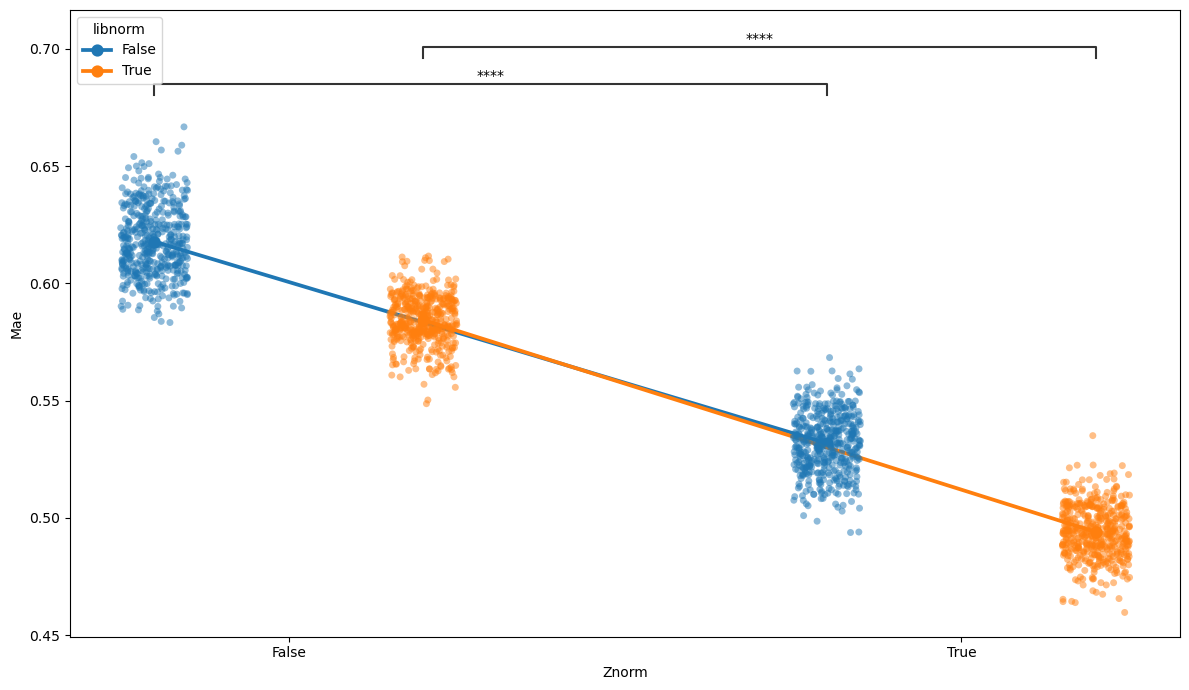

In [13]:
metric_x_point(
    df=test2, 
    cols=['norm_class', 'learnable','libnorm','znorm'],
    metrics=['mae'],
    figsize=(12,7),
    strip=True,
    sig='between',
    hue=True,
)